pancreas dataset from https://figshare.com/articles/dataset/scIB_pancreas_dataset/25953868

In [1]:
import scanpy as sc
import anndata
import pytorch_lightning as pl  
from scdiff.dataset import ScDataModule
from scdiff.ae import LightningAE
import os
import numpy as np
import pandas as pd

# Find Batch Effects in AE latent sapce

In [ ]:
pancreas = anndata.read_h5ad('../data/scIBPancreas.h5ad')
pancreas.obs

In [3]:
from scdiff.transform import NormalLog1pScaler

display(pancreas.obs['tech'].unique())
pancreas_scaler = NormalLog1pScaler()
pancreas.X = pancreas_scaler.fit_transform(pancreas.X)

['celseq', 'celseq2', 'fluidigmc1', 'smartseq2', 'inDrop1', 'inDrop2', 'inDrop3', 'inDrop4', 'smarter']
Categories (9, object): ['celseq', 'celseq2', 'fluidigmc1', 'inDrop1', ..., 'inDrop3', 'inDrop4', 'smarter', 'smartseq2']

In [4]:
pancreasModule = ScDataModule(pancreas, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=pancreas.X.shape[1])

log_dir = "../lightning_logs/pancreas/ae"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=log_dir
)

ae_path = "checkpoints/pancreas/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, pancreasModule)
    trainer.save_checkpoint(ae_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [5]:
import torch
from sklearn.preprocessing import StandardScaler

device = next(ae.parameters()).device
X_tensor = torch.tensor(pancreas.X, dtype=torch.float32).to(device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()
X_encoded.shape

(16382, 128)

In [8]:
batch_labels = pancreas.obs['tech']
batch_labels.shape

(16382,)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/tqdm/auto.py:21: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-11.03297   ,  13.3297    ],
        [-10.865371  ,  13.395873  ],
        [-10.819394  ,  13.404272  ],
        ...,
        [ 15.703993  ,   0.27635813],
        [ 15.714256  ,   0.07606439],
        [ 15.859944  ,   0.39904925]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

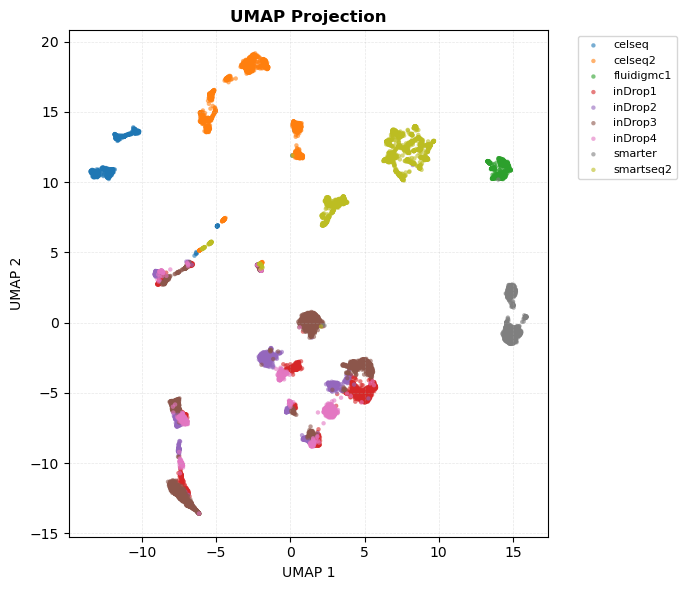

In [9]:
from scdiff.plot import umap_plot
umap_plot(X_encoded, batch_labels)

Batch Effects averaged over cell types

In [10]:
from scdiff.control import batch_directions 
cell_types = pancreas.obs['celltype']
batch_effects = batch_directions(X_encoded, batch_labels, cell_types=cell_types)
batch_effects

,celseq,celseq2,fluidigmc1,inDrop1,inDrop2,inDrop3,inDrop4,smarter,smartseq2
0,0.0,-0.768353,-5.092894,-1.109180,-2.357223,-1.460463,-1.937456,0.471786,-0.347178
1,0.0,-0.511896,-3.808590,-0.430479,-0.096033,0.118800,-0.308315,-1.992328,-0.154325
2,0.0,-0.125656,1.710801,1.205488,-0.020084,1.206460,0.128351,-0.550084,-0.601298
3,0.0,-0.909911,-0.312746,1.297573,0.025983,0.586978,1.172827,-0.184655,-1.585427
4,0.0,-0.719781,-2.711668,-3.060656,-3.139222,-3.044126,-2.483045,-1.215485,-0.957141
...,...,...,...,...,...,...,...,...,...
123,0.0,1.545932,0.629789,1.489183,2.002450,0.398463,1.572530,0.153586,1.251789
124,0.0,-1.679550,0.975188,0.913201,0.992033,1.912847,1.801414,2.044603,-0.703059
125,0.0,-0.184018,-3.798811,-0.948640,-0.430336,-1.420769,-0.317266,-2.730118,-2.252473
126,0.0,-1.460949,-0.464263,-0.902423,-0.573738,-0.823167,0.172687,-0.690245,0.027892


Move celseq2 batch effect

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[12.451824 , -7.8245277],
        [12.4847765, -7.8590508],
        [12.46879  , -7.8443127],
        ...,
        [-4.5536175,  9.866075 ],
        [-4.264763 ,  9.785131 ],
        [-4.6441865, 10.049854 ]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

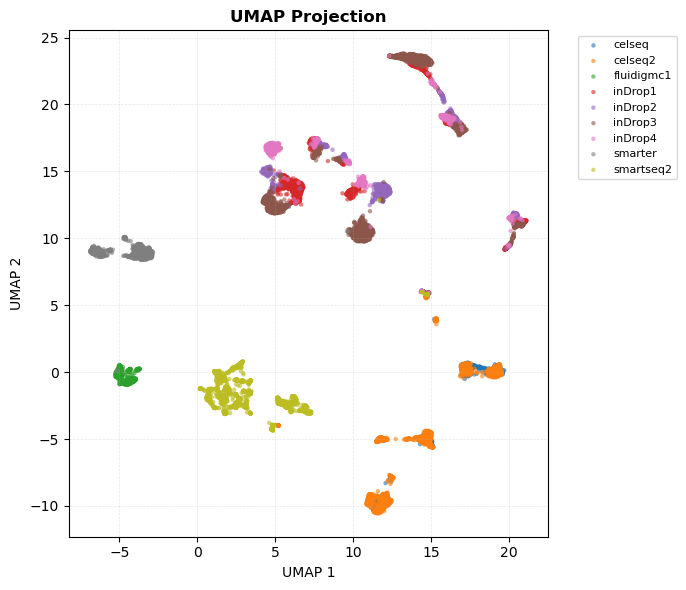

In [27]:
X_intervened = X_encoded.copy()
X_intervened[batch_labels == 'celseq2'] = X_encoded[batch_labels == 'celseq2'] - batch_effects['celseq2'].to_numpy().reshape(1, -1)
umap_plot(X_intervened, batch_labels)

align all batch effects to celseq

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[18.031345 ,  7.9542646],
        [17.7317   ,  8.35682  ],
        [17.80357  ,  8.111491 ],
        ...,
        [17.524252 ,  8.531697 ],
        [18.082504 ,  8.220976 ],
        [17.693378 ,  8.026344 ]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

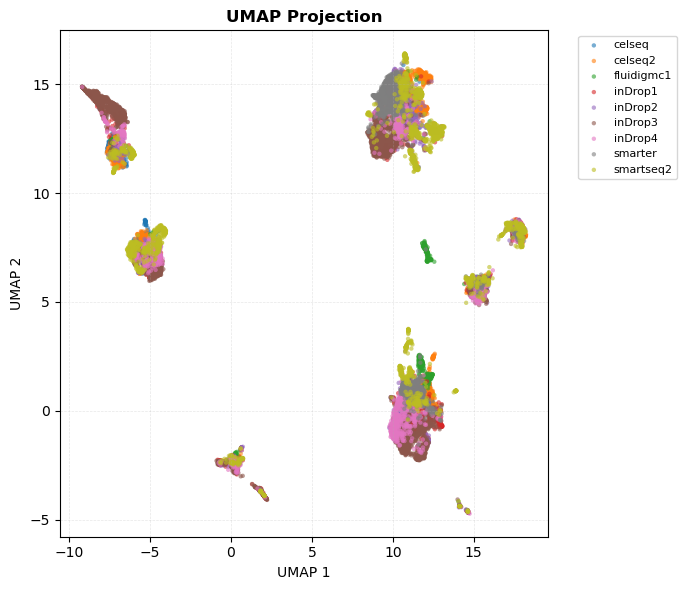

In [28]:
X_batch_moved = X_encoded.copy()
for batch in batch_effects.columns:
    X_batch_moved[batch_labels == batch] = X_encoded[batch_labels == batch] - batch_effects[batch].to_numpy().reshape(1, -1)
umap_plot(X_batch_moved, batch_labels)  

Batch Effects as grand mean shifts. Could be effected by batch-celltype interaction

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-2.183336 , 18.104275 ],
        [-2.1166096, 18.064173 ],
        [-2.2598584, 18.179075 ],
        ...,
        [15.900537 ,  0.8085533],
        [16.024643 ,  1.0467523],
        [15.936119 ,  0.5850538]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

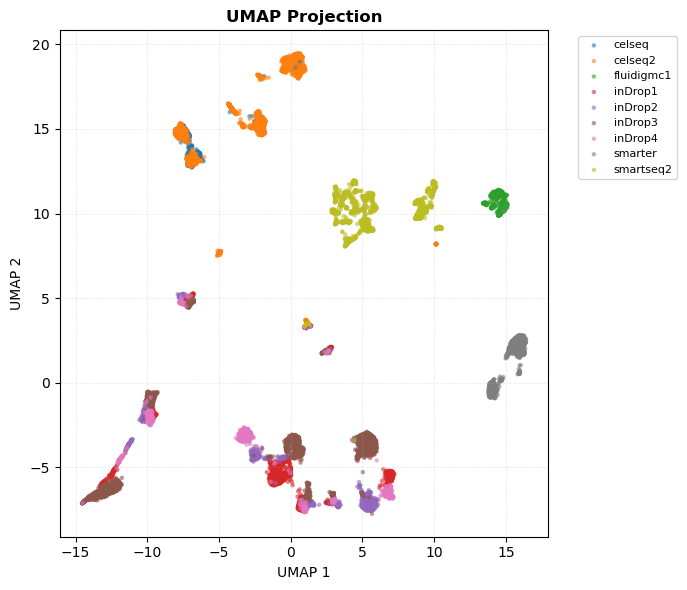

In [29]:
Grand_batch_effects = batch_directions(X_encoded, batch_labels, cell_types=None)
X_grand_batch_moved = X_encoded.copy()
X_grand_batch_moved[batch_labels == 'celseq2'] = X_encoded[batch_labels == 'celseq2'] - Grand_batch_effects['celseq2'].to_numpy().reshape(1, -1)
umap_plot(X_grand_batch_moved, batch_labels)

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


(array([[-9.223872  ,  0.5125162 ],
        [-9.091759  , -0.11612236],
        [-9.193144  ,  0.20090409],
        ...,
        [-8.787493  , -0.4422444 ],
        [-8.837084  , -0.01891815],
        [-8.906575  , -0.15021822]], shape=(16382, 2), dtype=float32),
 <Figure size 700x600 with 1 Axes>)

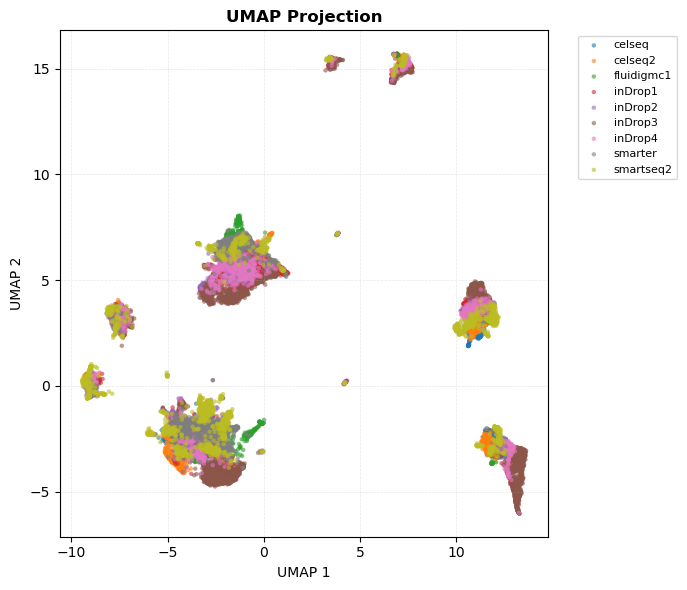

In [30]:
X_grand_batch_moved = X_encoded.copy()
for batch in Grand_batch_effects.columns:
    X_grand_batch_moved[batch_labels == batch] = X_encoded[batch_labels == batch] - Grand_batch_effects[batch].to_numpy().reshape(1, -1)
umap_plot(X_grand_batch_moved, batch_labels)

Performing UMAP on combined dataset (32764 samples, 128 features)...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


(array([[22.29341  ,  4.0567164],
        [22.467491 ,  3.3774886],
        [22.197212 ,  3.7896926],
        ...,
        [22.338459 ,  3.1457913],
        [22.088737 ,  3.4144921],
        [22.11977  ,  3.5415812]], shape=(16382, 2), dtype=float32),
 array([[22.330307 ,  4.0336056],
        [22.442009 ,  3.3231077],
        [22.178238 ,  3.73348  ],
        ...,
        [22.248241 ,  3.0445607],
        [22.11413  ,  3.406045 ],
        [22.250046 ,  3.4736278]], shape=(16382, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

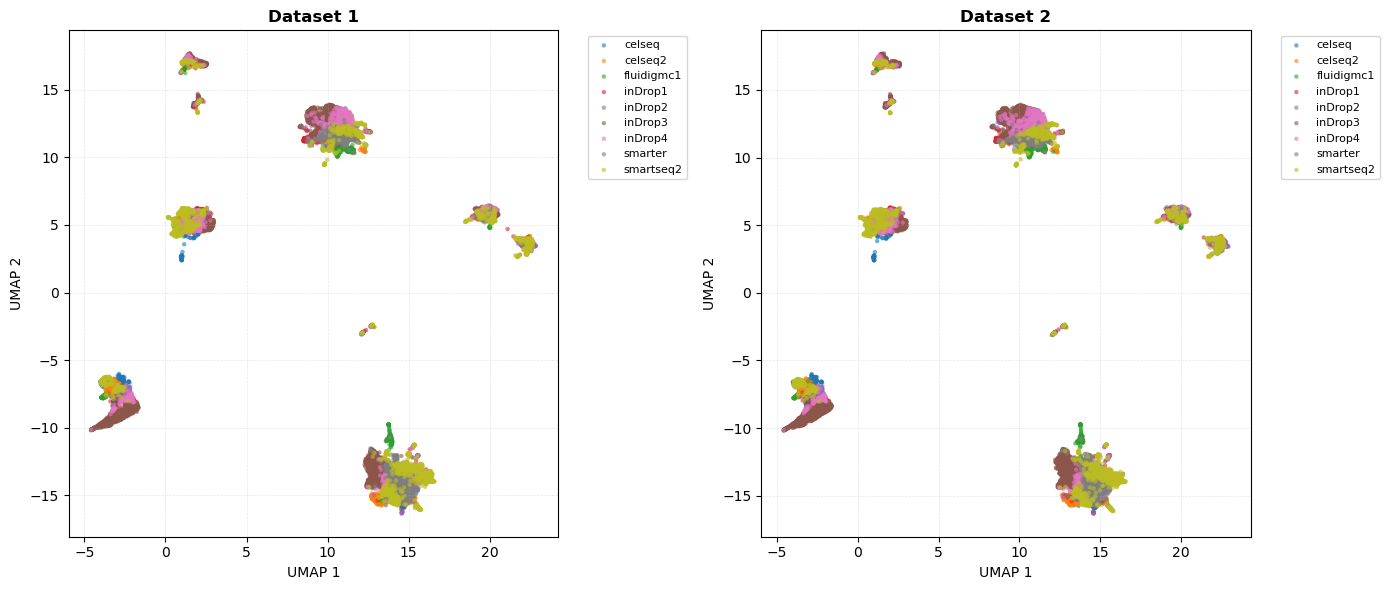

In [32]:
from scdiff.plot import compare_umap
compare_umap(X_batch_moved, X_grand_batch_moved, labels1=batch_labels, labels2=batch_labels)

# Interpolate in diffusion latent space.

In [36]:
from scdiff.lightning_diffusion import LightningDiffusion  
import anndata as ad

standard_scaler = StandardScaler()
scaled_X_encoded = standard_scaler.fit_transform(X_encoded)
latent_adata = ad.AnnData(scaled_X_encoded, obs=pancreas.obs.copy())
# use batches as labels
latent_dm = ScDataModule(latent_adata, label_key="tech",
                        encoder="LabelEncoder", batch_size=128, val_split=0.1)
latent_dm.setup()

dim = scaled_X_encoded.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1    

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999,
)

trainer = pl.Trainer(
    max_epochs=150,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/pancreas/diffusion"
)

diffusion_model_path = "checkpoints/pancreas/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)   
    trainer.save_checkpoint(diffusion_model_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | DenoisingUNet     | 7.2 M  | train
1 | diffusion | GaussianDiffusion | 7.2 M  | train
2 | ema_model | DenoisingUNet     | 7.2 M  | eval 
--------------------------------------------------------
7.2 M     Trainable params
7.2 M     Non-trainable params
14.3 M    Total params
57.366    Total estimated model params size (MB)
92        Modules in train mode
91        Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:527: Found 91 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 199: 100%|██████████| 116/116 [00:05<00:00, 21.01it/s, v_num=1, val_loss=0.157, train_loss=0.167]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 116/116 [00:05<00:00, 19.38it/s, v_num=1, val_loss=0.157, train_loss=0.167]


DDIM sampling: 100%|██████████| 50/50 [00:51<00:00,  1.04s/it]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (32764 samples, 128 features)...
UMAP completed. Generating visualizations...


(array([[-1.9437727, 14.790725 ],
        [-1.9066626, 14.640397 ],
        [-1.9360118, 14.7311125],
        ...,
        [-4.0209556, 10.508528 ],
        [-3.833991 , 10.114316 ],
        [-4.514982 , 11.216896 ]], shape=(16382, 2), dtype=float32),
 array([[-2.5614853, 20.579147 ],
        [-3.823266 , 14.539984 ],
        [-5.2532167, 15.515835 ],
        ...,
        [-5.0500946, 12.398395 ],
        [-5.5179763, 14.219647 ],
        [-5.0733566, 18.687304 ]], shape=(16382, 2), dtype=float32),
 <Figure size 1400x600 with 2 Axes>)

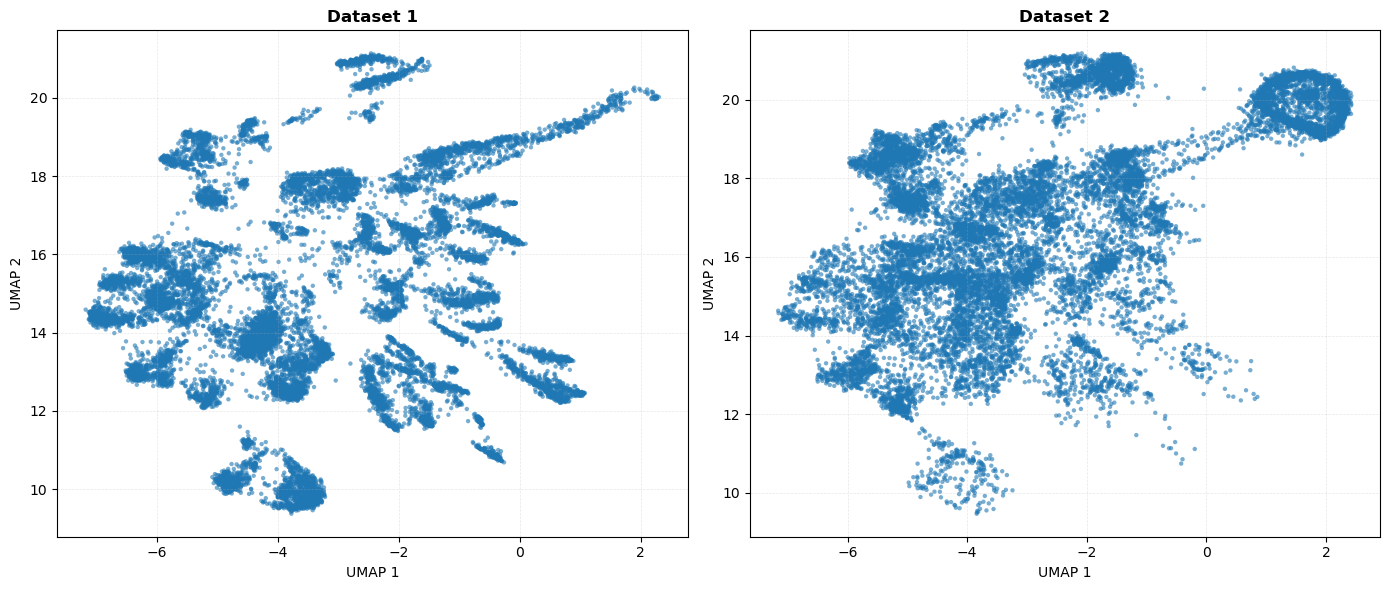

In [41]:
full_samples = diffusion.sample(num_samples=len(latent_adata),
                                sampling_timesteps=50,
                                ddim_sampling_eta=0,
                                use_ema=True,
                                clip_denoised=False)
compare_umap(latent_adata.X, full_samples)

DDIM sampling: 100%|██████████| 50/50 [02:41<00:00,  3.23s/it]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (32764 samples, 128 features)...
UMAP completed. Generating visualizations...


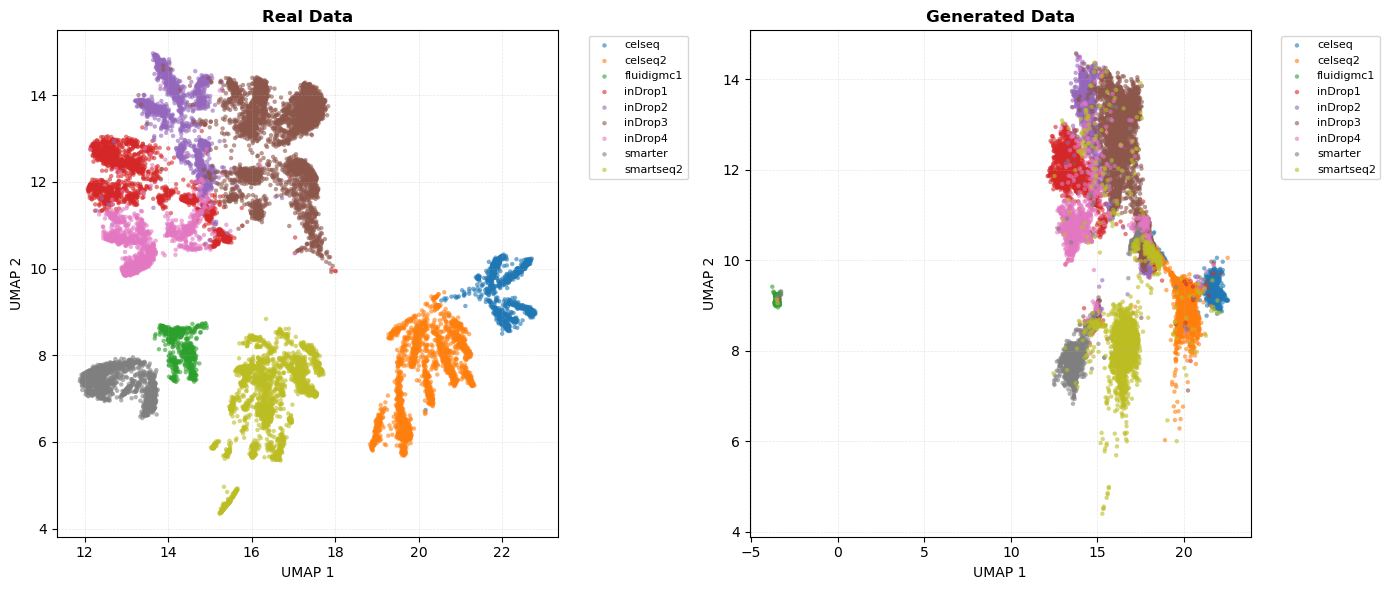

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
batch_tensor = torch.tensor(
    le.fit_transform(batch_labels), dtype=torch.long).to(device)

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(batch_tensor),
        sampling_timesteps=50,
        labels=batch_tensor,
        ddim_sampling_eta=0,
        use_ema=True,
        clip_denoised=False
    )

emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(batch_tensor),  
    labels2=le.inverse_transform(batch_tensor),
    title1="Real Data",
    title2="Generated Data",
    random_state=42
)   

DDIM sampling: 100%|██████████| 50/50 [01:49<00:00,  2.18s/it]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (32764 samples, 128 features)...
UMAP completed. Generating visualizations...


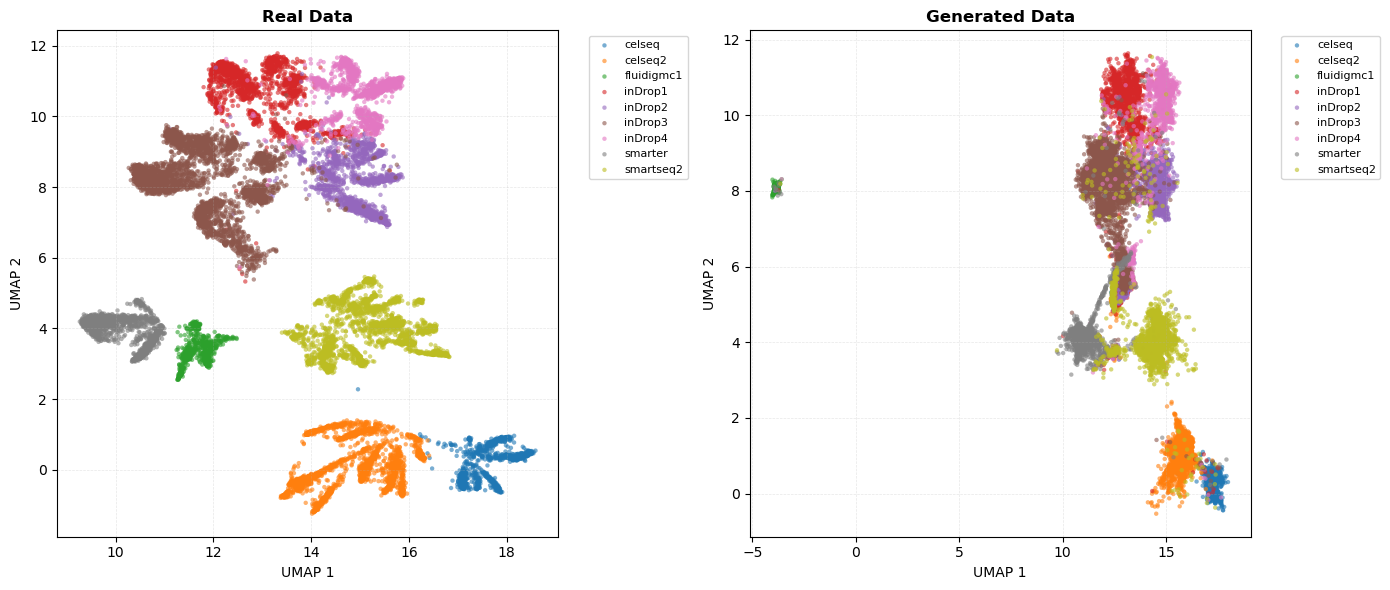

In [42]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
batch_tensor = torch.tensor(
    le.fit_transform(batch_labels), dtype=torch.long).to(device)

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(
        num_samples=len(batch_tensor),
        sampling_timesteps=50,
        labels=batch_tensor,
        ddim_sampling_eta=0,
        use_ema=True,
        clip_denoised=False,
        guidance_scale=0.0
    )

emb1, emb2, fig = compare_umap(
    latent_adata.X, 
    latent_samples.cpu().numpy(),
    labels1=le.inverse_transform(batch_tensor),  
    labels2=le.inverse_transform(batch_tensor),
    title1="Real Data",
    title2="Generated Data",
    random_state=42
)   

In [56]:
print("="*60)
print("Batch Distribution")
print("="*60)

batch_counts = batch_labels.value_counts()
print(batch_counts)

# 特别关注fluidigmc1
print(f"\nfluidigmc1 样本数: {(batch_labels == 'fluidigmc1').sum()}")
print(f"总样本数: {len(batch_labels)}")
print(f"占比: {100 * (batch_labels == 'fluidigmc1').sum() / len(batch_labels):.2f}%")

Batch Distribution
tech
inDrop3       3605
smartseq2     2394
celseq2       2285
inDrop1       1937
inDrop2       1724
smarter       1492
inDrop4       1303
celseq        1004
fluidigmc1     638
Name: count, dtype: int64

fluidigmc1 样本数: 638
总样本数: 16382
占比: 3.89%


In [57]:
# 获取模型
model = diffusion.ema_model if diffusion.hparams.use_ema else diffusion.model
model.eval()
device = next(model.parameters()).device

# 创建测试输入
torch.manual_seed(42)
n_test = 100
x_test = torch.randn(n_test, diffusion.hparams.input_dim, device=device)
t_test = torch.full((n_test,), 500, device=device, dtype=torch.long)

le = LabelEncoder()
le.fit(batch_labels)

def std_fn(x):
    return torch.std(x, dim=tuple(range(1, x.ndim)), keepdim=True)

print("="*60)
print("CFG Step-by-Step Analysis (cond_scale=0.0)")
print("="*60)

rescaled_phi = 0.7
cond_scale = 0.0

all_results = {}

with torch.no_grad():
    # 无条件预测
    null_logits = model.forward(x_test, t_test, labels=None, cond_drop_prob=1.0)
    null_std = std_fn(null_logits)

    print(f"\nUnconditional:")
    print(f"  Std per sample (mean): {null_std.mean().item():.4f}")

    for batch_name in le.classes_:
        batch_idx = le.transform([batch_name])[0]
        labels = torch.full((n_test,), batch_idx, device=device, dtype=torch.long)

        # 条件预测
        logits = model.forward(x_test, t_test, labels=labels)
        logits_std = std_fn(logits)

        # CFG计算
        scaled_logits = null_logits + (logits - null_logits) * cond_scale  # = null_logits
        scaled_std = std_fn(scaled_logits)

        # Rescaling
        std_ratio = logits_std / (scaled_std + 1e-8)
        rescaled_logits = scaled_logits * std_ratio

        # Interpolation
        final = rescaled_logits * rescaled_phi + scaled_logits * (1.0 - rescaled_phi)

        # 差异
        diff_from_null = torch.norm(final - null_logits, dim=1).mean().item()

        all_results[batch_name] = {
            'logits_std': logits_std.mean().item(),
            'scaled_std': scaled_std.mean().item(),
            'std_ratio': std_ratio.mean().item(),
            'diff_from_null': diff_from_null,
        }

# 打印结果
print(f"\n{'Batch':<15} {'Cond Std':>10} {'Scaled Std':>12} {'Std Ratio':>10} {'|Final-Null|':>12}")
print("-" * 65)
for batch_name in le.classes_:
    r = all_results[batch_name]
    flag = "⚠️" if abs(r['std_ratio'] - 1.0) > 0.1 or r['diff_from_null'] > 0.01 else ""
    print(f"{batch_name:<15} {r['logits_std']:>10.4f} {r['scaled_std']:>12.4f} {r['std_ratio']:>10.4f} {r['diff_from_null']:>12.6f} {flag}")

# 找问题
print("\n" + "="*60)
print("Problem Detection")
print("="*60)

for batch_name in le.classes_:
    r = all_results[batch_name]
    issues = []
    if abs(r['std_ratio'] - 1.0) > 0.1:
        issues.append(f"std_ratio={r['std_ratio']:.3f} (should be ~1.0)")
    if r['diff_from_null'] > 0.01:
        issues.append(f"final differs from unconditional by {r['diff_from_null']:.6f}")
    if issues:
        print(f"⚠️  {batch_name}: {', '.join(issues)}")

CFG Step-by-Step Analysis (cond_scale=0.0)

Unconditional:
  Std per sample (mean): 1.1692

Batch             Cond Std   Scaled Std  Std Ratio |Final-Null|
-----------------------------------------------------------------
celseq              1.1985       1.1692     1.0254     0.236183 ⚠️
celseq2             1.2132       1.1692     1.0382     0.350816 ⚠️
fluidigmc1          1.2513       1.1692     1.0710     0.650176 ⚠️
inDrop1             1.1821       1.1692     1.0111     0.116729 ⚠️
inDrop2             1.1779       1.1692     1.0076     0.096502 ⚠️
inDrop3             1.1754       1.1692     1.0055     0.098295 ⚠️
inDrop4             1.1832       1.1692     1.0121     0.123185 ⚠️
smarter             1.2014       1.1692     1.0281     0.265101 ⚠️
smartseq2           1.2026       1.1692     1.0289     0.268350 ⚠️

Problem Detection
⚠️  celseq: final differs from unconditional by 0.236183
⚠️  celseq2: final differs from unconditional by 0.350816
⚠️  fluidigmc1: final differs from uncond

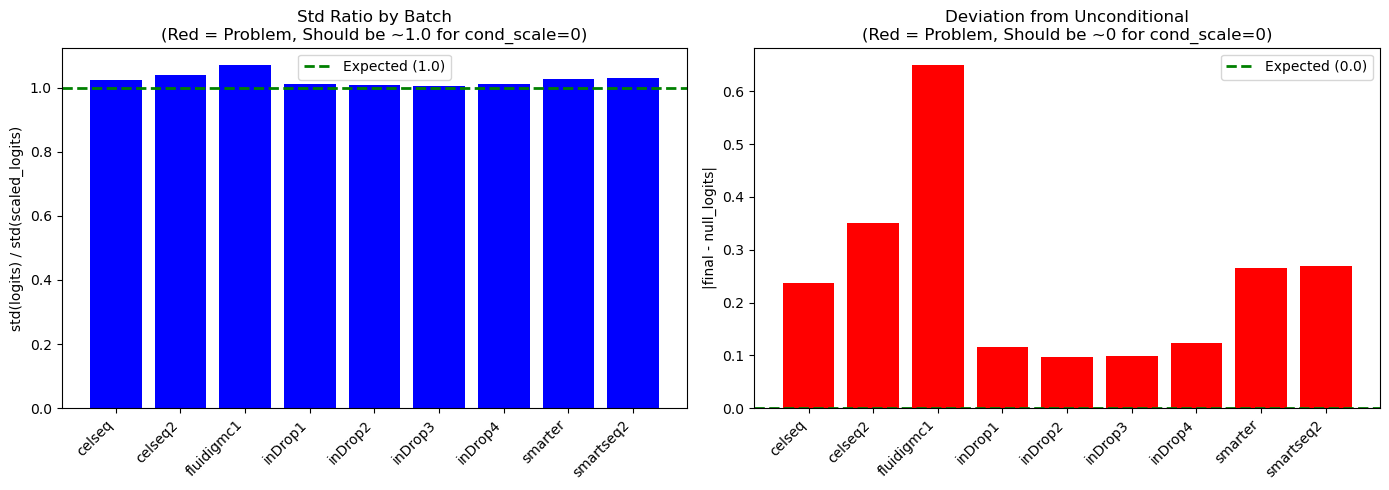

In [58]:
# Cell 3: 可视化std ratio问题
import matplotlib.pyplot as plt

batch_names = list(all_results.keys())
std_ratios = [all_results[b]['std_ratio'] for b in batch_names]
diff_from_nulls = [all_results[b]['diff_from_null'] for b in batch_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Std ratio
colors = ['red' if abs(r - 1.0) > 0.1 else 'blue' for r in std_ratios]
axes[0].bar(range(len(batch_names)), std_ratios, color=colors)
axes[0].axhline(1.0, color='green', linestyle='--', linewidth=2, label='Expected (1.0)')
axes[0].set_xticks(range(len(batch_names)))
axes[0].set_xticklabels(batch_names, rotation=45, ha='right')
axes[0].set_ylabel('std(logits) / std(scaled_logits)')
axes[0].set_title('Std Ratio by Batch\n(Red = Problem, Should be ~1.0 for cond_scale=0)')
axes[0].legend()

# Diff from null
colors = ['red' if d > 0.01 else 'blue' for d in diff_from_nulls]
axes[1].bar(range(len(batch_names)), diff_from_nulls, color=colors)
axes[1].axhline(0.0, color='green', linestyle='--', linewidth=2, label='Expected (0.0)')
axes[1].set_xticks(range(len(batch_names)))
axes[1].set_xticklabels(batch_names, rotation=45, ha='right')
axes[1].set_ylabel('|final - null_logits|')
axes[1].set_title('Deviation from Unconditional\n(Red = Problem, Should be ~0 for cond_scale=0)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [59]:
# Cell 4: 检查Label Embedding
import torch
import numpy as np

model = diffusion.ema_model if diffusion.hparams.use_ema else diffusion.model
device = next(model.parameters()).device

le = LabelEncoder()
le.fit(batch_labels)

print("="*60)
print("Label Embedding Analysis")
print("="*60)

label_embeddings = {}
with torch.no_grad():
    # Null embedding
    null_emb = model.null_label_emb.detach().cpu().numpy()
    label_embeddings['null'] = null_emb

    for batch_name in le.classes_:
        batch_idx = le.transform([batch_name])[0]
        labels = torch.tensor([batch_idx], device=device, dtype=torch.long)
        emb = model.label_embedding(labels).detach().cpu().numpy()[0]
        label_embeddings[batch_name] = emb

# 计算与null的距离
print(f"\n{'Batch':<15} {'Emb Norm':>10} {'Dist from Null':>15} {'Cosine Sim':>12}")
print("-" * 55)

for batch_name in le.classes_:
    emb = label_embeddings[batch_name]
    dist = np.linalg.norm(emb - null_emb)
    cos_sim = np.dot(emb, null_emb) / (np.linalg.norm(emb) * np.linalg.norm(null_emb) + 1e-8)
    print(f"{batch_name:<15} {np.linalg.norm(emb):>10.4f} {dist:>15.4f} {cos_sim:>12.4f}")

# 检查异常
print("\n" + "="*60)
print("Embedding Anomaly Check")
print("="*60)

emb_norms = {b: np.linalg.norm(label_embeddings[b]) for b in le.classes_}
mean_norm = np.mean(list(emb_norms.values()))
std_norm = np.std(list(emb_norms.values()))

for batch_name in le.classes_:
    if abs(emb_norms[batch_name] - mean_norm) > 2 * std_norm:
        print(f"⚠️  {batch_name} embedding norm ({emb_norms[batch_name]:.4f}) is {abs(emb_norms[batch_name] - mean_norm)/std_norm:.1f} std away from mean!")

Label Embedding Analysis

Batch             Emb Norm  Dist from Null   Cosine Sim
-------------------------------------------------------
celseq              7.1219         20.4562       0.3215
celseq2             6.3384         21.1678       0.2145
fluidigmc1          7.9605         21.4223       0.2067
inDrop1             6.4086         20.1724       0.3640
inDrop2             6.6355         20.2170       0.3556
inDrop3             6.5341         20.0163       0.3850
inDrop4             6.4505         20.3479       0.3381
smarter             6.7687         20.4601       0.3209
smartseq2           6.2197         21.0425       0.2328

Embedding Anomaly Check
⚠️  fluidigmc1 embedding norm (7.9605) is 2.5 std away from mean!


Direct Sampling Comparison


DDIM sampling: 100%|██████████| 50/50 [00:03<00:00, 15.14it/s]
/var/folders/5z/8hzvmhln5p36t4tdqc9c52z40000gn/T/ipykernel_78492/108063180.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([norms_none, norms_fluid, norms_celseq2],



使用同样的随机种子，比较最终采样结果：

|fluidigmc1(cfg=0) - unconditional|:
  Mean: 17112.472656
  Max:  20598.748047

|celseq2(cfg=0) - unconditional|:
  Mean: 10244.018555
  Max:  16971.574219

差异比例: fluidigmc1 / celseq2 = 1.67x

⚠️  即使guidance_scale=0.0，采样结果仍与无条件采样不同！
   这证明了CFG实现中的rescaling步骤引入了条件信息。


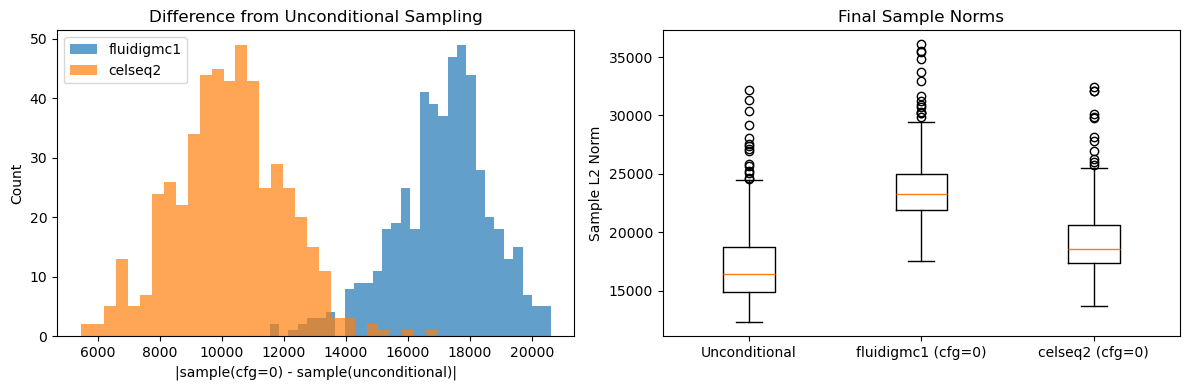

In [60]:
# Cell 5: 直接对比采样结果
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(batch_labels)

# 固定随机种子
torch.manual_seed(123)

n_test = 500  # 测试500个样本

print("="*60)
print("Direct Sampling Comparison")
print("="*60)

diffusion.eval()
with torch.no_grad():
    # 测试1: 完全无条件 (labels=None)
    samples_none = diffusion.sample(
        num_samples=n_test,
        sampling_timesteps=50,
        labels=None,  # 关键：不提供labels
        ddim_sampling_eta=0,
        use_ema=True,
        clip_denoised=False
    ).cpu().numpy()

    # 测试2: fluidigmc1 + guidance_scale=0
    torch.manual_seed(123)  # 同样的随机种子！
    fluidigmc1_idx = le.transform(['fluidigmc1'])[0]
    fluidigmc1_labels = torch.full((n_test,), fluidigmc1_idx, dtype=torch.long, device=device)

    samples_fluid_0 = diffusion.sample(
        num_samples=n_test,
        sampling_timesteps=50,
        labels=fluidigmc1_labels,
        guidance_scale=0.0,
        ddim_sampling_eta=0,
        use_ema=True,
        clip_denoised=False
    ).cpu().numpy()

    # 测试3: celseq2 + guidance_scale=0 (作为参照)
    torch.manual_seed(123)
    celseq2_idx = le.transform(['celseq2'])[0] if 'celseq2' in le.classes_ else le.transform([le.classes_[1]])[0]
    celseq2_labels = torch.full((n_test,), celseq2_idx, dtype=torch.long, device=device)

    samples_celseq2_0 = diffusion.sample(
        num_samples=n_test,
        sampling_timesteps=50,
        labels=celseq2_labels,
        guidance_scale=0.0,
        ddim_sampling_eta=0,
        use_ema=True,
        clip_denoised=False
    ).cpu().numpy()

# 计算差异
diff_fluid = np.linalg.norm(samples_fluid_0 - samples_none, axis=1)
diff_celseq2 = np.linalg.norm(samples_celseq2_0 - samples_none, axis=1)

print(f"\n使用同样的随机种子，比较最终采样结果：")
print(f"\n|fluidigmc1(cfg=0) - unconditional|:")
print(f"  Mean: {diff_fluid.mean():.6f}")
print(f"  Max:  {diff_fluid.max():.6f}")

print(f"\n|celseq2(cfg=0) - unconditional|:")
print(f"  Mean: {diff_celseq2.mean():.6f}")
print(f"  Max:  {diff_celseq2.max():.6f}")

print(f"\n差异比例: fluidigmc1 / celseq2 = {diff_fluid.mean() / (diff_celseq2.mean() + 1e-8):.2f}x")

if diff_fluid.mean() > 0.01 or diff_celseq2.mean() > 0.01:
    print(f"\n⚠️  即使guidance_scale=0.0，采样结果仍与无条件采样不同！")
    print("   这证明了CFG实现中的rescaling步骤引入了条件信息。")
else:
    print(f"\n✓ 采样结果与无条件采样相同，问题可能在其他地方。")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(diff_fluid, bins=30, alpha=0.7, label='fluidigmc1')
axes[0].hist(diff_celseq2, bins=30, alpha=0.7, label='celseq2')
axes[0].set_xlabel('|sample(cfg=0) - sample(unconditional)|')
axes[0].set_ylabel('Count')
axes[0].set_title('Difference from Unconditional Sampling')
axes[0].legend()

# 各batch的最终样本范数
norms_none = np.linalg.norm(samples_none, axis=1)
norms_fluid = np.linalg.norm(samples_fluid_0, axis=1)
norms_celseq2 = np.linalg.norm(samples_celseq2_0, axis=1)

axes[1].boxplot([norms_none, norms_fluid, norms_celseq2], 
                labels=['Unconditional', 'fluidigmc1 (cfg=0)', 'celseq2 (cfg=0)'])
axes[1].set_ylabel('Sample L2 Norm')
axes[1].set_title('Final Sample Norms')

plt.tight_layout()
plt.show()

样本数与embedding范数的相关系数: -0.6599


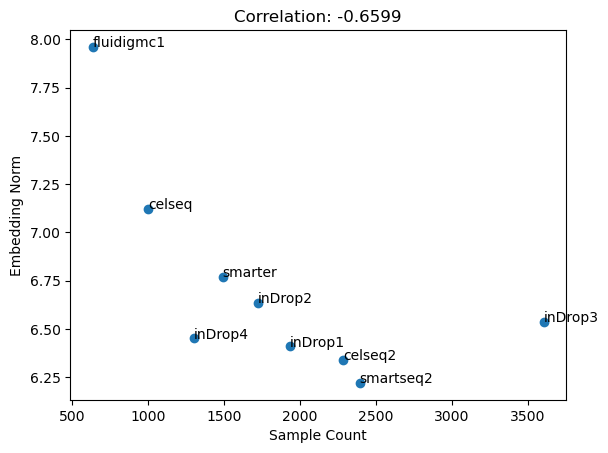

In [61]:
# 快速验证
import numpy as np

batch_counts = batch_labels.value_counts()
le = LabelEncoder()
le.fit(batch_labels)

model = diffusion.ema_model if diffusion.hparams.use_ema else diffusion.model
device = next(model.parameters()).device

counts = []
norms = []

with torch.no_grad():
    for batch_name in le.classes_:
        counts.append(batch_counts.get(batch_name, 0))
        batch_idx = le.transform([batch_name])[0]
        labels = torch.tensor([batch_idx], device=device, dtype=torch.long)
        emb = model.label_embedding(labels).detach().cpu().numpy()[0]
        norms.append(np.linalg.norm(emb))

corr = np.corrcoef(counts, norms)[0, 1]
print(f"样本数与embedding范数的相关系数: {corr:.4f}")

import matplotlib.pyplot as plt
plt.scatter(counts, norms)
for i, b in enumerate(le.classes_):
    plt.annotate(b, (counts[i], norms[i]))
plt.xlabel('Sample Count')
plt.ylabel('Embedding Norm')
plt.title(f'Correlation: {corr:.4f}')
plt.show()